# **Set-Up and Load Data**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.patches import Patch, FancyBboxPatch
import warnings
import seaborn as sns
import plotly.express as px
warnings.filterwarnings('ignore')

# Colour Palette
DARK_GREEN  = '#1b4d3e'
MID_GREEN   = '#4a7c59'
TEAL        = '#3aafa9'
ACCENT_GOLD = '#c39d63'
RED         = '#c0392b'
LIGHT_GRAY  = '#ecf0f1'

plt.rcParams.update({
    'font.family'       : 'sans-serif',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 12,
    'axes.titleweight'  : 'bold',
    'figure.facecolor'  : 'white',
    'axes.facecolor'    : 'white',
})

In [2]:
# Load Data
transaksi = pd.read_csv('/content/transaksi_harian.csv')
print(f"Raw rows : {len(transaksi):,}")

transaksi['date'] = pd.to_datetime(transaksi['date'])

# Data Quality Issues
issues = {
    'future_dates'    : transaksi[transaksi['date'] > '2026-03-31'].shape[0],
    'negative_amount' : transaksi[transaksi['total_amount'] <= 0].shape[0],
    'missing_outlet'  : transaksi['outlet_id'].isna().sum(),
    'duplicates'      : transaksi['transaction_id'].duplicated().sum(),
}
print("\n[Data Quality Issues Found]")
for k, v in issues.items():
    print(f"  {k:<20}: {v} baris")

# Filter Data
df = transaksi[
    (transaksi['date'] >= '2025-01-01') &
    (transaksi['date'] <= '2026-03-31')
].copy()

# Feature Engineering
DAY_MAP = {
    'Monday':'Senin', 'Tuesday':'Selasa', 'Wednesday':'Rabu',
    'Thursday':'Kamis', 'Friday':'Jumat',
    'Saturday':'Sabtu', 'Sunday':'Minggu'
}

df['hour']        = pd.to_datetime(df['time'], format='%H:%M').dt.hour
df['day_of_week'] = df['date'].dt.day_name().map(DAY_MAP)
df['month_year']  = df['date'].dt.to_period('M')
df['week']        = df['date'].dt.isocalendar().week.astype(int)

print(f"\nClean rows : {len(df):,}")
print(f"Date range : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"day_of_week sample: {df['day_of_week'].unique()}")

Raw rows : 16,323

[Data Quality Issues Found]
  future_dates        : 8 baris
  negative_amount     : 22 baris
  missing_outlet      : 15 baris
  duplicates          : 0 baris

Clean rows : 16,315
Date range : 2025-01-01 → 2026-03-31
day_of_week sample: ['Minggu' 'Jumat' 'Selasa' 'Senin' 'Sabtu' 'Kamis' 'Rabu']


# **Data Preprocessing**

In [3]:
# Monthly Revenue + Transaksi
monthly = df.groupby('month_year').agg(
    revenue=('total_amount', 'sum'),
    transaksi=('transaction_id', 'count')
).reset_index()
monthly['ts'] = monthly['month_year'].dt.to_timestamp()

# Province — top 5 & bottom 5
prov_all     = df.groupby('province')['total_amount'].sum().sort_values(ascending=False).reset_index()
prov_top5    = prov_all.head(5)
prov_bottom5 = prov_all.tail(5).sort_values('total_amount', ascending=False)

print("Top 5 Regional:")
print(prov_top5.to_string(index=False))
print("\nBottom 5 Regional:")
print(prov_bottom5.to_string(index=False))

Top 5 Regional:
   province  total_amount
DKI Jakarta     237281000
 Jawa Barat     143250000
     Banten      82101000
 Jawa Timur      80812000
Jawa Tengah      55726000

Bottom 5 Regional:
           province  total_amount
              Papua       2685000
Nusa Tenggara Timur       2565000
       Maluku Utara       2558000
           Bengkulu       2262000
             Maluku       2253000


# **Exploratory Data Analysis**

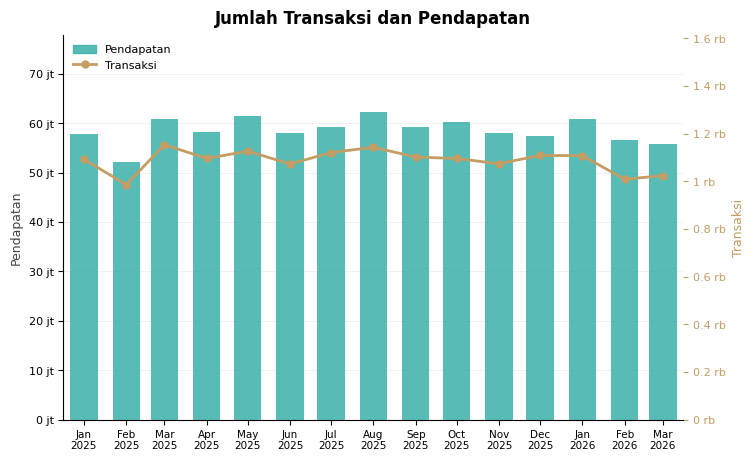

In [4]:
# Monthly Revenue + Transaksi
fig1 = plt.figure(figsize=(8, 5))
fig1.patch.set_facecolor('white')
ax1 = fig1.add_subplot(111)

ax1.bar(monthly['ts'], monthly['revenue'] / 1e6,
        width=20, color=TEAL, alpha=0.85, zorder=2)
ax1.set_ylabel('Pendapatan', fontsize=9, color='#444')
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f} jt'))
ax1.set_ylim(0, monthly['revenue'].max() / 1e6 * 1.25)
ax1.tick_params(axis='both', labelsize=8)
ax1.set_xlim(monthly['ts'].min() - pd.Timedelta(days=15),
             monthly['ts'].max() + pd.Timedelta(days=15))
ax1.set_xticks(monthly['ts'])
ax1.set_xticklabels([t.strftime('%b\n%Y') for t in monthly['ts']], fontsize=7.5, ha='center')
ax1.spines['left'].set_color('#ddd')
ax1.spines['bottom'].set_color('#ddd')
ax1.grid(axis='y', color='#eeeeee', linewidth=0.6, zorder=0)

ax1b = ax1.twinx()
ax1b.plot(monthly['ts'], monthly['transaksi'],
          color=ACCENT_GOLD, linewidth=2, marker='o', markersize=5, zorder=3)
ax1b.set_ylabel('Transaksi', fontsize=9, color=ACCENT_GOLD)
ax1b.set_ylim(0, monthly['transaksi'].max() * 1.4)
ax1b.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1000:.2g} rb'))
ax1b.tick_params(axis='y', labelsize=8, colors=ACCENT_GOLD)
ax1b.spines['top'].set_visible(False)
ax1b.spines['right'].set_color(ACCENT_GOLD)

legend_handles = [
    Patch(color=TEAL, alpha=0.85, label='Pendapatan'),
    plt.Line2D([0], [0], color=ACCENT_GOLD, linewidth=2,
               marker='o', markersize=5, label='Transaksi')
]
ax1.legend(handles=legend_handles, fontsize=8, loc='upper left', frameon=False)
ax1.set_title('Jumlah Transaksi dan Pendapatan', pad=8)

plt.show()

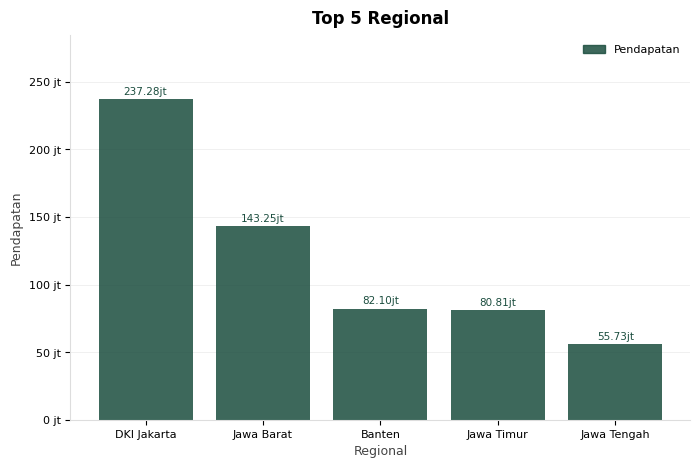

In [5]:
# Top 5 Regional
fig2 = plt.figure(figsize=(8, 5))
fig2.patch.set_facecolor('white')
ax2 = fig2.add_subplot(111)

bars2 = ax2.bar(prov_top5['province'], prov_top5['total_amount'] / 1e6,
                color=DARK_GREEN, alpha=0.85, zorder=2)
ax2.set_ylabel('Pendapatan', fontsize=9, color='#444')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.0f} jt'))
ax2.set_xlabel('Regional', fontsize=9, color='#444')
ax2.tick_params(axis='both', labelsize=8)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 2,
             f'{h:.2f}jt', ha='center', va='bottom', fontsize=7.5, color=DARK_GREEN)
ax2.set_ylim(0, prov_top5['total_amount'].max() / 1e6 * 1.2)
ax2.set_title('Top 5 Regional', pad=8)
ax2.spines['left'].set_color('#ddd')
ax2.spines['bottom'].set_color('#ddd')
ax2.grid(axis='y', color='#eeeeee', linewidth=0.6, zorder=0)
ax2.legend(handles=[Patch(color=DARK_GREEN, alpha=0.85, label='Pendapatan')],
           fontsize=8, loc='upper right', frameon=False)

plt.show()

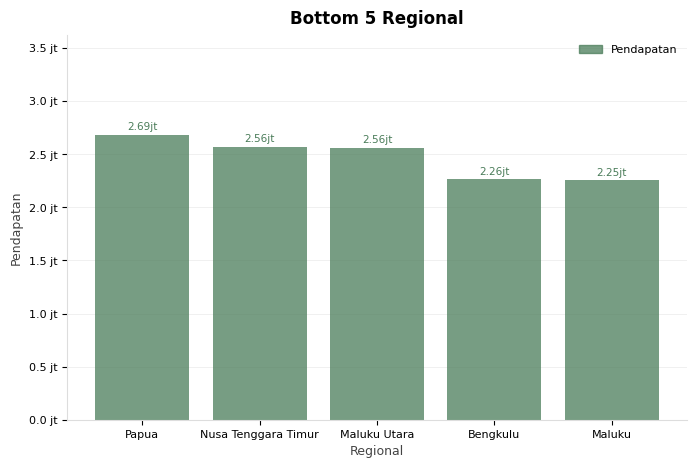

In [6]:
# Bottom 5 Regional
fig3 = plt.figure(figsize=(8, 5))
fig3.patch.set_facecolor('white')
ax3 = fig3.add_subplot(111)

bars3 = ax3.bar(prov_bottom5['province'], prov_bottom5['total_amount'] / 1e6,
                color=MID_GREEN, alpha=0.75, zorder=2)
ax3.set_ylabel('Pendapatan', fontsize=9, color='#444')
ax3.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:.1f} jt'))
ax3.set_xlabel('Regional', fontsize=9, color='#444')
ax3.tick_params(axis='both', labelsize=8)
for bar in bars3:
    h = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2, h + 0.03,
             f'{h:.2f}jt', ha='center', va='bottom', fontsize=7.5, color=MID_GREEN)
ax3.set_ylim(0, prov_bottom5['total_amount'].max() / 1e6 * 1.35)
ax3.set_title('Bottom 5 Regional', pad=8)
ax3.spines['left'].set_color('#ddd')
ax3.spines['bottom'].set_color('#ddd')
ax3.grid(axis='y', color='#eeeeee', linewidth=0.6, zorder=0)
ax3.legend(handles=[Patch(color=MID_GREEN, alpha=0.75, label='Pendapatan')],
           fontsize=8, loc='upper right', frameon=False)

plt.show()

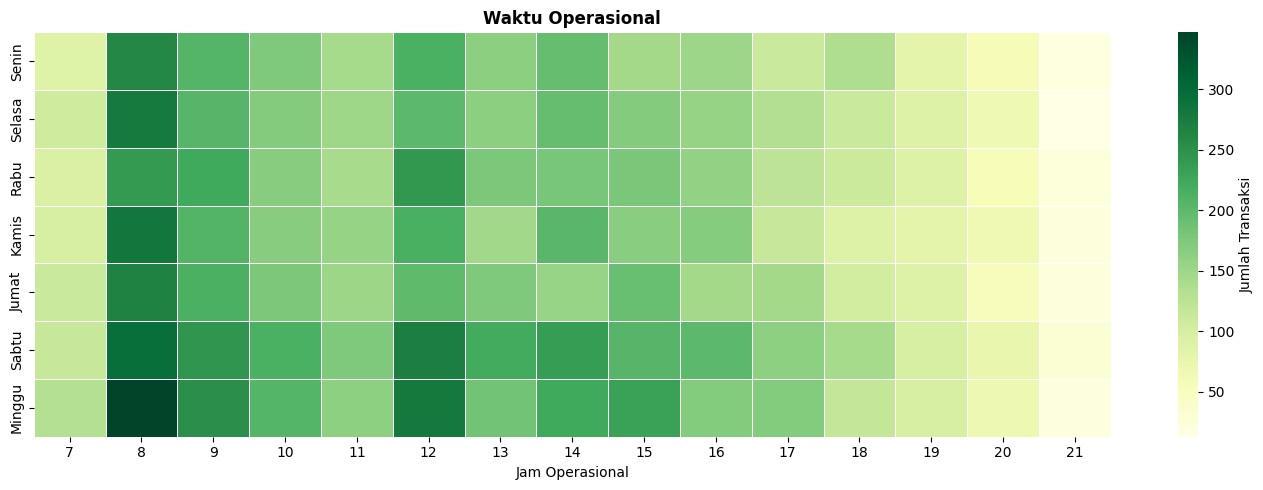

In [7]:
# Operating Time

DOW_ORDER = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']

heatmap_data = (
    df.groupby(['day_of_week', 'hour'])['transaction_id']
    .count()
    .unstack(fill_value=0)
    .reindex(DOW_ORDER)
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    heatmap_data,
    cmap='YlGn',
    linewidths=0.4,
    annot=False,
    cbar_kws={'label': 'Jumlah Transaksi'},
    ax=ax
)
ax.set_title('Waktu Operasional')
ax.set_xlabel('Jam Operasional')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.savefig('3b_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

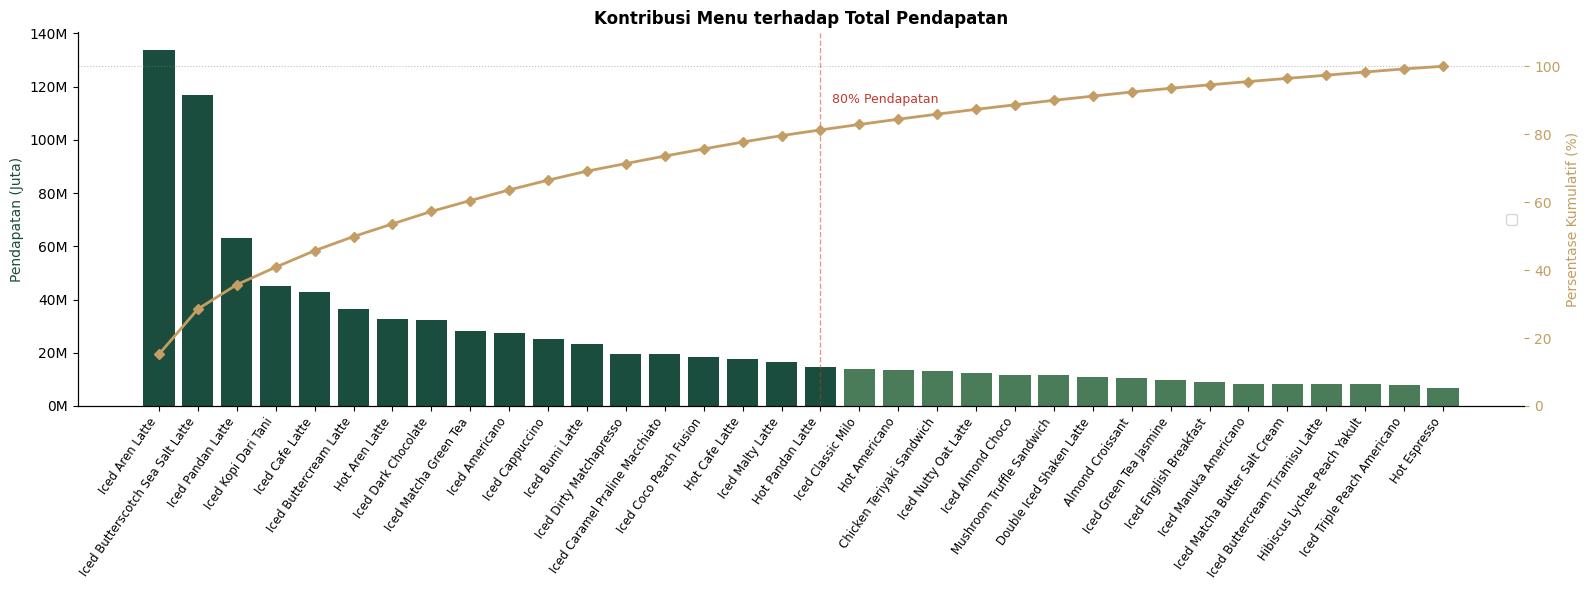


[3c] 18 menu teratas = 80% dari total revenue
     Sisanya 16 menu = 20% revenue


In [8]:
# Pareto Chart Menu
menu_rev = (
    df.groupby('menu_name')['total_amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
menu_rev['cumulative_pct'] = (
    menu_rev['total_amount'].cumsum() / menu_rev['total_amount'].sum() * 100
)

# Garis 80% (Pareto threshold)
idx_80 = (menu_rev['cumulative_pct'] >= 80).idxmax()

fig, ax1 = plt.subplots(figsize=(16, 6))

COLORS_BAR = [
    DARK_GREEN if i <= idx_80 else MID_GREEN
    for i in range(len(menu_rev))
]
ax1.bar(
    menu_rev['menu_name'], menu_rev['total_amount'],
    color=COLORS_BAR, zorder=2
)
ax1.set_ylabel('Pendapatan (Juta)', color=DARK_GREEN)
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
ax1.tick_params(axis='x', rotation=55)
for tick in ax1.get_xticklabels():
    tick.set_horizontalalignment('right')
    tick.set_fontsize(8.5)

ax2 = ax1.twinx()
ax2.plot(
    menu_rev['menu_name'], menu_rev['cumulative_pct'],
    color=ACCENT_GOLD, marker='D', linewidth=2, markersize=5, zorder=3
)
#ax2.axhline(80, color=RED, linestyle='--', linewidth=1.2, alpha=0.7, label='80% threshold')
ax2.axhline(100, color='gray', linestyle=':', linewidth=0.8, alpha=0.5)
ax2.set_ylabel('Persentase Kumulatif (%)', color=ACCENT_GOLD)
ax2.set_ylim(0, 110)
ax2.tick_params(axis='y', colors=ACCENT_GOLD)
ax2.spines['right'].set_color(ACCENT_GOLD)
ax2.legend(loc='center right')

# Annotation garis 80%
ax1.axvline(idx_80, color=RED, linestyle='--', linewidth=1, alpha=0.5)
ax1.text(
    idx_80 + 0.3,
    menu_rev['total_amount'].max() * 0.85,
    f"80% Pendapatan",
    color=RED, fontsize=9
)

ax1.set_title('Kontribusi Menu terhadap Total Pendapatan')
plt.tight_layout()
plt.savefig('3c_pareto_menu.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n[3c] {idx_80+1} menu teratas = 80% dari total revenue")
print(f"     Sisanya {len(menu_rev)-(idx_80+1)} menu = 20% revenue")